# Feature Extraction & Image Classification
### Andrii Kudenko

### Objective

The goal of this notebook is to build and compare multiple image classification models for the FitFolio item submission workflow.

Given a product image, each model should predict:
- **category**: Accessories / Apparel / Shoes
- **gender**: men / women / unisex
- **color**: one of 12 predefined FitFolio colors

Why these:
1. they are crucial for search filtering,
2. the public dataset has those fields clearly defined.

Experiment Plan
This notebook compares four model approaches:
1. a **custom CNN trained from scratch**,
2. a **pretrained ResNet18**,
3. a **pretrained EfficientNet-B0**,
4. a **pretrained Vision Transformer (ViT-B/16)**.

All models will use the same dataset, preprocessing pipeline, train/validation split, and evaluation metrics to ensure a fair comparison.

The final goal is to select the most suitable model for integration into the FitFolio application.

### Setup and Imports

In [ ]:
# Core data handling
import os
from pathlib import Path
from collections import Counter

# Data analysis
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from PIL import Image

# Metrics and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
# Project paths
DATA_DIR = Path("data")
IMAGES_DIR = DATA_DIR / "images"
STYLES_CSV = DATA_DIR / "styles.csv"

# Best available device
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)
print("Styles CSV exists:", STYLES_CSV.exists())
print("Images folder exists:", IMAGES_DIR.exists())

Using device: mps
Styles CSV exists: True
Images folder exists: True


In [ ]:
from rembg import remove


def remove_background_save(input_path: str | Path, output_path: str | Path) -> Path:
    """Read an image, remove its background with rembg, and write a PNG with alpha."""
    src = Path(input_path)
    dst = Path(output_path)
    if not src.is_file():
        raise FileNotFoundError(f"Input image not found: {src}")
    dst.parent.mkdir(parents=True, exist_ok=True)
    dst.write_bytes(remove(src.read_bytes()))
    return dst.resolve()


# Example:
# remove_background_save(IMAGES_DIR / "15970.jpg", DATA_DIR / "no_bg" / "15970.png")


### Inspect Data

In this section, we load the dataset and perform an initial inspection.

The dataset consists of:
- a CSV file containing metadata for each item
- an images folder where each image is named using the item ID

We will:
1. load the dataset,
2. inspect its structure,
3. check for missing or inconsistent values,
4. understand label distributions.

In [3]:
# Load dataset with safe parsing (skip corrupted rows)
df = pd.read_csv(STYLES_CSV, on_bad_lines="skip")

# Display basic info
print("Shape:", df.shape)
df.head()

Shape: (44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [4]:
# Column names and types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  str    
 2   masterCategory      44424 non-null  str    
 3   subCategory         44424 non-null  str    
 4   articleType         44424 non-null  str    
 5   baseColour          44409 non-null  str    
 6   season              44403 non-null  str    
 7   year                44423 non-null  float64
 8   usage               44107 non-null  str    
 9   productDisplayName  44417 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 3.4 MB


In [5]:
# Keep only relevant columns for this project
df = df[["id", "gender", "masterCategory", "baseColour"]]

# Drop missing values
df = df.dropna()

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (44409, 4)


,id,gender,masterCategory,baseColour
0,15970,Men,Apparel,Navy Blue
1,39386,Men,Apparel,Blue
2,59263,Women,Accessories,Silver
3,21379,Men,Apparel,Black
4,53759,Men,Apparel,Grey


In [6]:
print("\nCategory distribution:")
print(df["masterCategory"].value_counts())

print("\nGender distribution:")
print(df["gender"].value_counts())

print("\nColor distribution (raw):")
print(df["baseColour"].value_counts().head(15))


Category distribution:
masterCategory
Apparel           21391
Accessories       11274
Footwear           9219
Personal Care      2394
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

Gender distribution:
gender
Men       22136
Women     18627
Unisex     2161
Boys        830
Girls       655
Name: count, dtype: int64

Color distribution (raw):
baseColour
Black        9728
White        5538
Blue         4918
Brown        3494
Grey         2741
Red          2455
Green        2115
Pink         1860
Navy Blue    1789
Purple       1640
Silver       1090
Yellow        778
Beige         749
Gold          628
Maroon        581
Name: count, dtype: int64


### Data Cleaning and Label Preparation

The raw dataset contains additional categories and gender labels that are outside the scope of the FitFolio classification task.

In this section, we:
- keep only the relevant categories,
- standardize category and gender labels,
- map raw color names to the 12 predefined FitFolio colors,
- remove rows that do not fit the target label space.

In [7]:
# Keep only the categories relevant to the application
allowed_categories = ["Apparel", "Accessories", "Footwear"]
allowed_genders = ["Men", "Women", "Unisex"]

df = df[df["masterCategory"].isin(allowed_categories)]
df = df[df["gender"].isin(allowed_genders)]

print("Shape after category/gender filtering:", df.shape)
print("\nFiltered category distribution:")
print(df["masterCategory"].value_counts())

print("\nFiltered gender distribution:")
print(df["gender"].value_counts())

Shape after category/gender filtering: (40399, 4)

Filtered category distribution:
masterCategory
Apparel        20065
Accessories    11229
Footwear        9105
Name: count, dtype: int64

Filtered gender distribution:
gender
Men       21509
Women     16779
Unisex     2111
Name: count, dtype: int64


In [ ]:
# Rename category values to match application terminology
df["masterCategory"] = df["masterCategory"].replace({
    "Footwear": "Shoes"
})

# Convert gender labels to lowercase for consistency
df["gender"] = df["gender"].str.lower()

print("\nStandardized category distribution:")
print(df["masterCategory"].value_counts())

print("\nStandardized gender distribution:")
print(df["gender"].value_counts())


Standardized category distribution:
masterCategory
Apparel        20065
Accessories    11229
Shoes           9105
Name: count, dtype: int64

Standardized gender distribution:
gender
men       21509
women     16779
unisex     2111
Name: count, dtype: int64


In [9]:
# Map dataset color labels to the 12 FitFolio colors
COLOR_MAP = {
    "Black": "black",
    "White": "white",
    "Grey": "grey",
    "Gray": "grey",
    "Charcoal": "grey",
    "Steel": "grey",

    "Blue": "blue",
    "Navy Blue": "blue",
    "Turquoise Blue": "blue",
    "Teal": "blue",

    "Red": "red",
    "Maroon": "red",
    "Burgundy": "red",
    "Rust": "red",

    "Green": "green",
    "Olive": "green",
    "Lime Green": "green",
    "Sea Green": "green",

    "Brown": "brown",
    "Coffee Brown": "brown",
    "Tan": "brown",

    "Beige": "beige",
    "Cream": "beige",
    "Off White": "beige",
    "Khaki": "beige",
    "Taupe": "beige",
    "Mushroom Brown": "beige",

    "Yellow": "yellow",
    "Mustard": "yellow",
    "Gold": "yellow",

    "Orange": "orange",
    "Coral": "orange",
    "Peach": "orange",

    "Pink": "pink",
    "Rose": "pink",

    "Purple": "purple",
    "Lavender": "purple",
    "Violet": "purple",
}

In [10]:
# Convert raw colors into the 12 target colors
df["color_12"] = df["baseColour"].map(COLOR_MAP)

print("\nMapped color distribution:")
print(df["color_12"].value_counts(dropna=False).head(20))


Mapped color distribution:
color_12
black     9315
blue      6317
white     5039
brown     3353
grey      3187
red       2733
green     2291
NaN       1886
purple    1603
pink      1405
beige     1404
yellow    1278
orange     588
Name: count, dtype: int64


In [11]:
# Inspect raw colors that were not mapped
unmapped_colors = sorted(df[df["color_12"].isna()]["baseColour"].dropna().unique())

print("Unmapped colors:")
print(unmapped_colors)
print("\nNumber of unmapped colors:", len(unmapped_colors))

Unmapped colors:
['Bronze', 'Copper', 'Fluorescent Green', 'Grey Melange', 'Magenta', 'Mauve', 'Metallic', 'Multi', 'Nude', 'Silver', 'Skin']

Number of unmapped colors: 11


In [12]:
COLOR_MAP.update({
    "Bronze": "brown",
    "Copper": "brown",
    "Fluorescent Green": "green",
    "Grey Melange": "grey",
    "Magenta": "pink",
    "Mauve": "purple",
    "Nude": "beige",
    "Skin": "beige",
    "Silver": "grey",
})

In [13]:
df["color_12"] = df["baseColour"].map(COLOR_MAP)

In [14]:
# Inspect raw colors that were not mapped
unmapped_colors = sorted(df[df["color_12"].isna()]["baseColour"].dropna().unique())

print("Unmapped colors:")
print(unmapped_colors)
print("\nNumber of unmapped colors:", len(unmapped_colors))

Unmapped colors:
['Metallic', 'Multi']

Number of unmapped colors: 2


In [ ]:
unmapped_colors = sorted(df[df["color_12"].isna()]["baseColour"].dropna().unique())
print(unmapped_colors)

['Metallic', 'Multi']


In [16]:
# Metallic and Multi are more ambiguous than others, so I will drop them
df = df.dropna(subset=["color_12"])

In [17]:
unmapped_colors = sorted(df[df["color_12"].isna()]["baseColour"].dropna().unique())
print(unmapped_colors)

[]


### Image Path Construction

The image files in the dataset are named using the item ID.
In this section, we construct the full image path for each row and keep only the rows whose image file exists.

This ensures that the training pipeline only uses samples with both:
- valid labels
- available image files

In [18]:
# Build full image paths using the item ID
df["image_path"] = df["id"].astype(int).astype(str) + ".jpg"
df["image_path"] = df["image_path"].apply(lambda x: IMAGES_DIR / x)

df[["id", "image_path"]].head()

,id,image_path
0,15970,data/images/15970.jpg
1,39386,data/images/39386.jpg
2,59263,data/images/59263.jpg
3,21379,data/images/21379.jpg
4,53759,data/images/53759.jpg


In [19]:
# Check whether each referenced image file exists
df["file_exists"] = df["image_path"].apply(lambda x: x.exists())

print("Existing files:", df["file_exists"].sum())
print("Missing files:", (~df["file_exists"]).sum())

Existing files: 39977
Missing files: 5


In [20]:
# Remove rows whose image file is missing
df = df[df["file_exists"]].copy()

print("Shape after file validation:", df.shape)
df.head()

Shape after file validation: (39977, 7)


,id,gender,masterCategory,baseColour,color_12,image_path,file_exists
0,15970,men,Apparel,Navy Blue,blue,data/images/15970.jpg,True
1,39386,men,Apparel,Blue,blue,data/images/39386.jpg,True
2,59263,women,Accessories,Silver,grey,data/images/59263.jpg,True
3,21379,men,Apparel,Black,black,data/images/21379.jpg,True
4,53759,men,Apparel,Grey,grey,data/images/53759.jpg,True


In [21]:
# Inspect one sample image path
sample_row = df.iloc[0]
print("Sample ID:", sample_row["id"])
print("Sample image path:", sample_row["image_path"])
print("Category:", sample_row["masterCategory"])
print("Gender:", sample_row["gender"])
print("Color:", sample_row["color_12"])

Sample ID: 15970
Sample image path: data/images/15970.jpg
Category: Apparel
Gender: men
Color: blue


### Train/Validation Split

Machine learning models require numeric target labels rather than strings.
In this section, we encode the category, gender, and color labels into integer values.

After encoding, we split the dataset into training and validation sets.
A stratified split is used to preserve the overall class distribution in both subsets.

In [22]:
# Convert string labels into integer class IDs
category_encoder = LabelEncoder()
gender_encoder = LabelEncoder()
color_encoder = LabelEncoder()

df["category_label"] = category_encoder.fit_transform(df["masterCategory"])
df["gender_label"] = gender_encoder.fit_transform(df["gender"])
df["color_label"] = color_encoder.fit_transform(df["color_12"])

print("Category classes:", list(category_encoder.classes_))
print("Gender classes:", list(gender_encoder.classes_))
print("Color classes:", list(color_encoder.classes_))

Category classes: ['Accessories', 'Apparel', 'Shoes']
Gender classes: ['men', 'unisex', 'women']
Color classes: ['beige', 'black', 'blue', 'brown', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'white', 'yellow']


In [23]:
# Preview encoded labels alongside original values
df[[
    "masterCategory", "category_label",
    "gender", "gender_label",
    "color_12", "color_label"
]].head()

,masterCategory,category_label,gender,gender_label,color_12,color_label
0,Apparel,1,men,0,blue,2
1,Apparel,1,men,0,blue,2
2,Accessories,0,women,2,grey,5
3,Apparel,1,men,0,black,1
4,Apparel,1,men,0,grey,5


In [27]:
# Split data into train and validation subsets
train_df, val_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["category_label"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (27983, 10)
Validation shape: (11994, 10)


In [28]:
# Verify category distribution after splitting
print("Train category distribution:")
print(train_df["masterCategory"].value_counts(normalize=True))

print("\nValidation category distribution:")
print(val_df["masterCategory"].value_counts(normalize=True))

Train category distribution:
masterCategory
Apparel        0.495444
Accessories    0.278240
Shoes          0.226316
Name: proportion, dtype: float64

Validation category distribution:
masterCategory
Apparel        0.495414
Accessories    0.278222
Shoes          0.226363
Name: proportion, dtype: float64


In [29]:
print("Train gender distribution:")
print(train_df["gender"].value_counts(normalize=True))

print("\nValidation gender distribution:")
print(val_df["gender"].value_counts(normalize=True))


print("\nTrain color distribution:")
print(train_df["color_12"].value_counts(normalize=True))

print("\nValidation color distribution:")
print(val_df["color_12"].value_counts(normalize=True))

Train gender distribution:
gender
men       0.538077
women     0.408105
unisex    0.053818
Name: proportion, dtype: float64

Validation gender distribution:
gender
men       0.530849
women     0.419126
unisex    0.050025
Name: proportion, dtype: float64

Train color distribution:
color_12
black     0.232212
blue      0.157846
white     0.125112
grey      0.110031
brown     0.086624
red       0.068685
green     0.058071
purple    0.040132
pink      0.037701
beige     0.036308
yellow    0.032377
orange    0.014902
Name: proportion, dtype: float64

Validation color distribution:
color_12
black     0.234784
blue      0.158329
white     0.128231
grey      0.105386
brown     0.089211
red       0.067450
green     0.055945
purple    0.040854
pink      0.037519
beige     0.037019
yellow    0.031016
orange    0.014257
Name: proportion, dtype: float64


### Dataset and DataLoader

To train image classification models, we need a custom dataset that:
- loads an image from disk,
- applies image transformations,
- returns the image together with its encoded labels.

We then wrap the dataset with DataLoader objects to create mini-batches for training and validation.

In [30]:
# Define image preprocessing transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [31]:
class FashionDataset(Dataset):
    """
    Custom dataset for FitFolio image classification.

    Each sample consists of:
    - an RGB image loaded from disk,
    - three encoded labels: category, gender, and color.
    """
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load the image and convert it to RGB
        image = Image.open(row["image_path"]).convert("RGB")

        # Extract encoded labels
        labels = {
            "category": int(row["category_label"]),
            "gender": int(row["gender_label"]),
            "color": int(row["color_label"]),
        }

        # Apply preprocessing if provided
        if self.transform:
            image = self.transform(image)

        return image, labels

In [32]:
# Create training and validation datasets
train_dataset = FashionDataset(train_df, transform=train_transform)
val_dataset = FashionDataset(val_df, transform=val_transform)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 27983
Validation dataset size: 11994


In [33]:
# Inspect one dataset sample
sample_image, sample_labels = train_dataset[0]

print("Image shape:", sample_image.shape)
print("Labels:", sample_labels)

Image shape: torch.Size([3, 224, 224])
Labels: {'category': 2, 'gender': 0, 'color': 1}


In [34]:
# Wrap datasets into dataloaders for batching
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [35]:
# Inspect one batch from the training loader
images, labels = next(iter(train_loader))

print("Batch image tensor shape:", images.shape)
print("Category labels:", labels["category"][:5])
print("Gender labels:", labels["gender"][:5])
print("Color labels:", labels["color"][:5])

Batch image tensor shape: torch.Size([32, 3, 224, 224])
Category labels: tensor([1, 2, 1, 2, 0])
Gender labels: tensor([2, 0, 0, 1, 2])
Color labels: tensor([ 1,  3, 10, 10, 10])


### Model A - Custom CNN from Scratch

In this section, we implement a convolutional neural network trained from scratch.

Unlike pretrained models, this network learns all visual features directly from the dataset.
This provides a baseline for comparing the effectiveness of transfer learning approaches.

In [36]:
class SimpleCNN(nn.Module):
    """
    Custom CNN trained from scratch for multi-task classification.
    """

    def __init__(self, num_categories, num_genders, num_colors):
        super().__init__()

        # Feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56 -> 28
        )

        # Make feature size independent of input resolution
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Shared representation
        self.fc_shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
        )

        # Task-specific heads
        self.category_head = nn.Linear(256, num_categories)
        self.gender_head = nn.Linear(256, num_genders)
        self.color_head = nn.Linear(256, num_colors)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.fc_shared(x)

        return {
            "category": self.category_head(x),
            "gender": self.gender_head(x),
            "color": self.color_head(x),
        }

In [37]:
num_categories = len(category_encoder.classes_)
num_genders = len(gender_encoder.classes_)
num_colors = len(color_encoder.classes_)

model_scratch = SimpleCNN(
    num_categories=num_categories,
    num_genders=num_genders,
    num_colors=num_colors
).to(device)

print(model_scratch)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc_shared): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=256, bias=True)
    (2): ReLU()
  )
  (category_head): Linear(in_features=256, out_features=3, bias=True)
  (gender_head): Linear(in_features=256, out_features=3, bias=True)
  (color_head): Linear(in_features=256, out_features=12, bias=True)
)


#### Training Setup

In this section, we define:
- loss functions for each prediction task,
- an optimizer to update model weights.

Since this is a multi-task model, we compute separate losses for:
- category classification,
- gender classification,
- color classification,

and combine them into a single training objective.

In [38]:
# Define loss functions for each task
criterion_category = nn.CrossEntropyLoss()
criterion_gender = nn.CrossEntropyLoss()
criterion_color = nn.CrossEntropyLoss()

In [39]:
# Define optimizer
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

In [40]:
# Training function
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)

        targets = {
            k: v.to(device) for k, v in labels.items()
        }

        optimizer.zero_grad()

        outputs = model(images)

        loss_category = criterion_category(outputs["category"], targets["category"])
        loss_gender = criterion_gender(outputs["gender"], targets["gender"])
        loss_color = criterion_color(outputs["color"], targets["color"])

        loss = loss_category + loss_gender + loss_color

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
# Evaluation function
def evaluate(model, loader, device):
    model.eval()

    total_loss = 0
    correct = {"category": 0, "gender": 0, "color": 0}
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            targets = {k: v.to(device) for k, v in labels.items()}

            outputs = model(images)

            loss_category = criterion_category(outputs["category"], targets["category"])
            loss_gender = criterion_gender(outputs["gender"], targets["gender"])
            loss_color = criterion_color(outputs["color"], targets["color"])

            loss = loss_category + loss_gender + loss_color
            total_loss += loss.item()

            preds = {
                k: torch.argmax(v, dim=1)
                for k, v in outputs.items()
            }

            for k in correct:
                correct[k] += (preds[k] == targets[k]).sum().item()

            total += images.size(0)

    return {
        "loss": total_loss / len(loader),
        "category_acc": correct["category"] / total,
        "gender_acc": correct["gender"] / total,
        "color_acc": correct["color"] / total,
    }

In [43]:
# Train!
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, device)
    val_metrics = evaluate(model_scratch, val_loader, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f}")
    print(f"Val Category Acc: {val_metrics['category_acc']:.4f}")
    print(f"Val Gender Acc: {val_metrics['gender_acc']:.4f}")
    print(f"Val Color Acc: {val_metrics['color_acc']:.4f}")
    print("-" * 40)

Epoch 1/5
Train Loss: 3.4604
Val Loss: 2.9325
Val Category Acc: 0.7430
Val Gender Acc: 0.6258
Val Color Acc: 0.4898
----------------------------------------
Epoch 2/5
Train Loss: 2.6632
Val Loss: 2.4237
Val Category Acc: 0.8383
Val Gender Acc: 0.6697
Val Color Acc: 0.5667
----------------------------------------
Epoch 3/5
Train Loss: 2.2082
Val Loss: 2.0288
Val Category Acc: 0.9033
Val Gender Acc: 0.7053
Val Color Acc: 0.6344
----------------------------------------
Epoch 4/5
Train Loss: 2.0005
Val Loss: 1.8789
Val Category Acc: 0.9256
Val Gender Acc: 0.7314
Val Color Acc: 0.6627
----------------------------------------
Epoch 5/5
Train Loss: 1.8626
Val Loss: 1.7943
Val Category Acc: 0.9290
Val Gender Acc: 0.7390
Val Color Acc: 0.6748
----------------------------------------


The custom CNN provided a strong baseline, especially for category classification.  
However, its lower gender and color accuracy indicates that training from scratch is less effective for fine-grained predictions, making it a useful comparison point for later transfer-learning models.

Potential improvements for this model include tuning the learning rate, increasing training epochs, adding data augmentation, and expanding the network depth. In this notebook, the model is kept relatively simple so it can serve as a fair baseline against pretrained architectures.

### Model B - ResNet18

In this section, we use a pretrained ResNet18 backbone.

Unlike the custom CNN, this model starts with visual features learned from ImageNet.
This usually improves convergence speed and downstream accuracy, especially for fine-grained tasks such as color prediction.

In [44]:
# ImageNet-style preprocessing for pretrained ResNet18
train_transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [45]:
# Create ResNet-specific datasets and dataloaders
train_dataset_resnet = FashionDataset(train_df, transform=train_transform_resnet)
val_dataset_resnet = FashionDataset(val_df, transform=val_transform_resnet)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=32, shuffle=True)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=32, shuffle=False)

In [46]:
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained ResNet18 backbone
resnet_backbone = resnet18(weights=ResNet18_Weights.DEFAULT)

# Extract feature size and remove original classifier
in_features = resnet_backbone.fc.in_features
resnet_backbone.fc = nn.Identity()

In [47]:
class ResNetMultiHead(nn.Module):
    """
    Multi-task classifier built on top of a pretrained ResNet18 backbone.
    """

    def __init__(self, backbone, num_categories, num_genders, num_colors):
        super().__init__()
        self.backbone = backbone

        self.fc_shared = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU()
        )

        self.category_head = nn.Linear(256, num_categories)
        self.gender_head = nn.Linear(256, num_genders)
        self.color_head = nn.Linear(256, num_colors)

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc_shared(x)

        return {
            "category": self.category_head(x),
            "gender": self.gender_head(x),
            "color": self.color_head(x),
        }

In [48]:
model_resnet = ResNetMultiHead(
    resnet_backbone,
    num_categories,
    num_genders,
    num_colors
).to(device)

print(model_resnet)

ResNetMultiHead(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

#### Training Setup

In [49]:
optimizer_resnet = torch.optim.Adam(model_resnet.parameters(), lr=1e-4)

In [50]:
# Train!
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_resnet, train_loader_resnet, optimizer_resnet, device)
    val_metrics = evaluate(model_resnet, val_loader_resnet, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f}")
    print(f"Val Category Acc: {val_metrics['category_acc']:.4f}")
    print(f"Val Gender Acc: {val_metrics['gender_acc']:.4f}")
    print(f"Val Color Acc: {val_metrics['color_acc']:.4f}")
    print("-" * 40)

Epoch 1/5
Train Loss: 1.4014
Val Loss: 1.0433
Val Category Acc: 0.9936
Val Gender Acc: 0.9060
Val Color Acc: 0.7556
----------------------------------------
Epoch 2/5
Train Loss: 0.9368
Val Loss: 1.0124
Val Category Acc: 0.9957
Val Gender Acc: 0.9238
Val Color Acc: 0.7499
----------------------------------------
Epoch 3/5
Train Loss: 0.7268
Val Loss: 0.9726
Val Category Acc: 0.9947
Val Gender Acc: 0.9261
Val Color Acc: 0.7630
----------------------------------------
Epoch 4/5
Train Loss: 0.5385
Val Loss: 1.0947
Val Category Acc: 0.9958
Val Gender Acc: 0.9260
Val Color Acc: 0.7464
----------------------------------------
Epoch 5/5
Train Loss: 0.3653
Val Loss: 1.2403
Val Category Acc: 0.9962
Val Gender Acc: 0.9200
Val Color Acc: 0.7523
----------------------------------------


### Model C - EfficientNet-B0

In this section, we evaluate EfficientNet-B0 as a stronger pretrained CNN alternative.

EfficientNet is designed to scale model depth, width, and resolution more efficiently than standard CNNs.
This makes it a strong candidate for improving fine-grained predictions such as color classification.

In [51]:
# ImageNet-style preprocessing for pretrained EfficientNet-B0
train_transform_effnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transform_effnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [52]:
# EfficientNet datasets and loaders
train_dataset_effnet = FashionDataset(train_df, transform=train_transform_effnet)
val_dataset_effnet = FashionDataset(val_df, transform=val_transform_effnet)

train_loader_effnet = DataLoader(train_dataset_effnet, batch_size=32, shuffle=True)
val_loader_effnet = DataLoader(val_dataset_effnet, batch_size=32, shuffle=False)

In [53]:
# Load pretrained EfficientNet-B0
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

effnet_backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/akudenko/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 24.6MB/s]


In [54]:
# Extract feature size from EfficientNet classifier
in_features_effnet = effnet_backbone.classifier[1].in_features

# Remove original classifier
effnet_backbone.classifier = nn.Identity()

In [55]:
class EfficientNetMultiHead(nn.Module):
    """
    Multi-task classifier built on top of a pretrained EfficientNet-B0 backbone.
    """

    def __init__(self, backbone, num_categories, num_genders, num_colors):
        super().__init__()
        self.backbone = backbone

        self.fc_shared = nn.Sequential(
            nn.Linear(in_features_effnet, 256),
            nn.ReLU()
        )

        self.category_head = nn.Linear(256, num_categories)
        self.gender_head = nn.Linear(256, num_genders)
        self.color_head = nn.Linear(256, num_colors)

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc_shared(x)

        return {
            "category": self.category_head(x),
            "gender": self.gender_head(x),
            "color": self.color_head(x),
        }

In [56]:
model_effnet = EfficientNetMultiHead(
    effnet_backbone,
    num_categories,
    num_genders,
    num_colors
).to(device)

print(model_effnet)

EfficientNetMultiHead(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
           

#### Training Setup

In [57]:
optimizer_effnet = torch.optim.Adam(model_effnet.parameters(), lr=1e-4)

In [58]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_effnet, train_loader_effnet, optimizer_effnet, device)
    val_metrics = evaluate(model_effnet, val_loader_effnet, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f}")
    print(f"Val Category Acc: {val_metrics['category_acc']:.4f}")
    print(f"Val Gender Acc: {val_metrics['gender_acc']:.4f}")
    print(f"Val Color Acc: {val_metrics['color_acc']:.4f}")
    print("-" * 40)

Epoch 1/5
Train Loss: 1.5852
Val Loss: 1.0336
Val Category Acc: 0.9936
Val Gender Acc: 0.9169
Val Color Acc: 0.7447
----------------------------------------
Epoch 2/5
Train Loss: 1.0049
Val Loss: 0.9507
Val Category Acc: 0.9952
Val Gender Acc: 0.9236
Val Color Acc: 0.7659
----------------------------------------
Epoch 3/5
Train Loss: 0.8375
Val Loss: 0.9183
Val Category Acc: 0.9959
Val Gender Acc: 0.9302
Val Color Acc: 0.7751
----------------------------------------
Epoch 4/5
Train Loss: 0.7178
Val Loss: 0.9438
Val Category Acc: 0.9968
Val Gender Acc: 0.9324
Val Color Acc: 0.7731
----------------------------------------
Epoch 5/5
Train Loss: 0.6083
Val Loss: 0.9777
Val Category Acc: 0.9958
Val Gender Acc: 0.9280
Val Color Acc: 0.7691
----------------------------------------


EfficientNet provided slightly better performance, particularly for color classification, but at a significantly higher computational cost compared to ResNet.

### Model D - ViT-B/16

In this section, we evaluate a Vision Transformer model.

Unlike CNN-based models, ViT processes images as sequences of patches and applies self-attention mechanisms. This allows it to capture global relationships in the image, rather than relying on local convolutional filters.

In [ ]:
# Load pretrained ViT-B/16
from torchvision.models import vit_b_16, ViT_B_16_Weights

vit_backbone = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/akudenko/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:15<00:00, 22.6MB/s] 


In [60]:
# Remove classifier
in_features_vit = vit_backbone.heads.head.in_features

vit_backbone.heads.head = nn.Identity()

In [61]:
class ViTMultiHead(nn.Module):
    def __init__(self, backbone, num_categories, num_genders, num_colors):
        super().__init__()
        self.backbone = backbone

        self.fc_shared = nn.Sequential(
            nn.Linear(in_features_vit, 256),
            nn.ReLU()
        )

        self.category_head = nn.Linear(256, num_categories)
        self.gender_head = nn.Linear(256, num_genders)
        self.color_head = nn.Linear(256, num_colors)

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc_shared(x)

        return {
            "category": self.category_head(x),
            "gender": self.gender_head(x),
            "color": self.color_head(x),
        }

In [62]:
model_vit = ViTMultiHead(
    vit_backbone,
    num_categories,
    num_genders,
    num_colors
).to(device)

print(model_vit)

ViTMultiHead(
  (backbone): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1):

#### Training Setup

In [63]:
# Same optimizer as for ResNet
optimizer_vit = torch.optim.Adam(model_vit.parameters(), lr=5e-5)

In [64]:
# Train!
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_vit, train_loader, optimizer_vit, device)
    val_metrics = evaluate(model_vit, val_loader, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f}")
    print(f"Val Category Acc: {val_metrics['category_acc']:.4f}")
    print(f"Val Gender Acc: {val_metrics['gender_acc']:.4f}")
    print(f"Val Color Acc: {val_metrics['color_acc']:.4f}")
    print("-" * 40)

Epoch 1/5
Train Loss: 1.3929
Val Loss: 1.0505
Val Category Acc: 0.9929
Val Gender Acc: 0.9181
Val Color Acc: 0.7412
----------------------------------------
Epoch 2/5
Train Loss: 0.8709
Val Loss: 1.0165
Val Category Acc: 0.9947
Val Gender Acc: 0.9258
Val Color Acc: 0.7431
----------------------------------------
Epoch 3/5
Train Loss: 0.6725
Val Loss: 0.9455
Val Category Acc: 0.9957
Val Gender Acc: 0.9231
Val Color Acc: 0.7670
----------------------------------------
Epoch 4/5
Train Loss: 0.5019
Val Loss: 1.0014
Val Category Acc: 0.9964
Val Gender Acc: 0.9244
Val Color Acc: 0.7728
----------------------------------------
Epoch 5/5
Train Loss: 0.3500
Val Loss: 1.1204
Val Category Acc: 0.9962
Val Gender Acc: 0.9284
Val Color Acc: 0.7663
----------------------------------------


The Vision Transformer achieved strong results across all three tasks and performed competitively with the CNN-based transfer learning models. However, its accuracy gains over ResNet18 were small, while training time was significantly higher. This suggests that although ViT is a powerful modern architecture, it may be less practical for this project than lighter pretrained CNN alternatives.

### Models Comparison

This section compares all evaluated models using the same dataset and validation split.

The goal is to identify:
- the strongest model in terms of predictive performance,
- the most practical model for deployment in the FitFolio application.

In [69]:
from sklearn.metrics import classification_report, confusion_matrix

def get_predictions(model, loader, device, task_name):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            targets = labels[task_name].to(device)

            outputs = model(images)
            preds = outputs[task_name].argmax(dim=1)

            y_true.extend(targets.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

In [70]:
models = {
    "SimpleCNN": model_scratch,
    "ResNet18": model_resnet,
    "EfficientNet": model_effnet,
    "ViT": model_vit
}

for name, model_instance in models.items():
    print(f"\n===== {name} =====")

    y_true, y_pred = get_predictions(model_instance, val_loader, device, "color")

    print(classification_report(
        y_true,
        y_pred,
        target_names=list(color_encoder.classes_)
    ))


===== SimpleCNN =====
              precision    recall  f1-score   support

       beige       0.46      0.41      0.43       444
       black       0.74      0.79      0.77      2816
        blue       0.80      0.71      0.75      1899
       brown       0.65      0.73      0.69      1070
       green       0.60      0.78      0.68       671
        grey       0.50      0.49      0.50      1264
      orange       0.56      0.57      0.56       171
        pink       0.60      0.63      0.61       450
      purple       0.79      0.53      0.64       490
         red       0.74      0.71      0.73       809
       white       0.64      0.64      0.64      1538
      yellow       0.68      0.56      0.61       372

    accuracy                           0.67     11994
   macro avg       0.65      0.63      0.63     11994
weighted avg       0.68      0.67      0.67     11994


===== ResNet18 =====
              precision    recall  f1-score   support

       beige       0.09      0.82

^ I had a mistake, as I used the same loaders for all the models, but there are different for different models


===== SimpleCNN =====
              precision    recall  f1-score   support

       beige       0.46      0.41      0.43       444
       black       0.74      0.79      0.77      2816
        blue       0.80      0.71      0.75      1899
       brown       0.65      0.73      0.69      1070
       green       0.60      0.78      0.68       671
        grey       0.50      0.49      0.50      1264
      orange       0.56      0.57      0.56       171
        pink       0.60      0.63      0.61       450
      purple       0.79      0.53      0.64       490
         red       0.74      0.71      0.73       809
       white       0.64      0.64      0.64      1538
      yellow       0.68      0.56      0.61       372

    accuracy                           0.67     11994
   macro avg       0.65      0.63      0.63     11994
weighted avg       0.68      0.67      0.67     11994



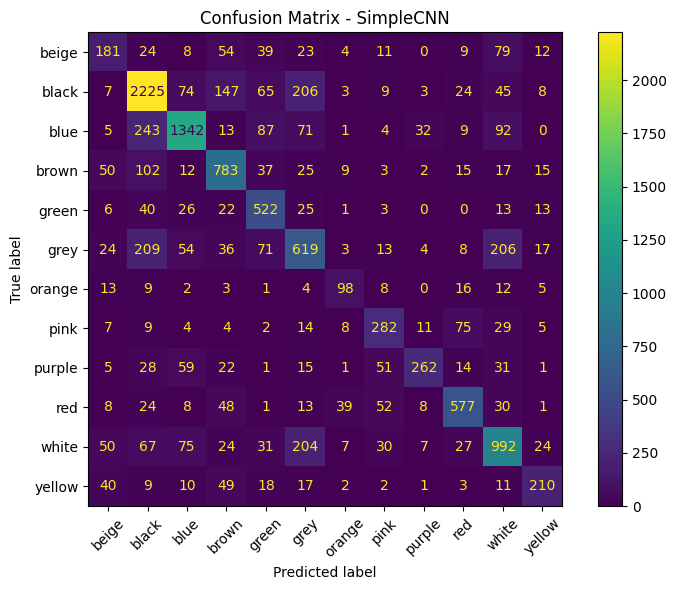


===== ResNet18 =====
              precision    recall  f1-score   support

       beige       0.55      0.63      0.59       444
       black       0.82      0.85      0.84      2816
        blue       0.85      0.76      0.80      1899
       brown       0.82      0.72      0.77      1070
       green       0.67      0.75      0.71       671
        grey       0.65      0.56      0.61      1264
      orange       0.54      0.63      0.58       171
        pink       0.69      0.64      0.66       450
      purple       0.78      0.63      0.70       490
         red       0.72      0.81      0.76       809
       white       0.70      0.85      0.77      1538
      yellow       0.74      0.67      0.71       372

    accuracy                           0.75     11994
   macro avg       0.71      0.71      0.71     11994
weighted avg       0.76      0.75      0.75     11994



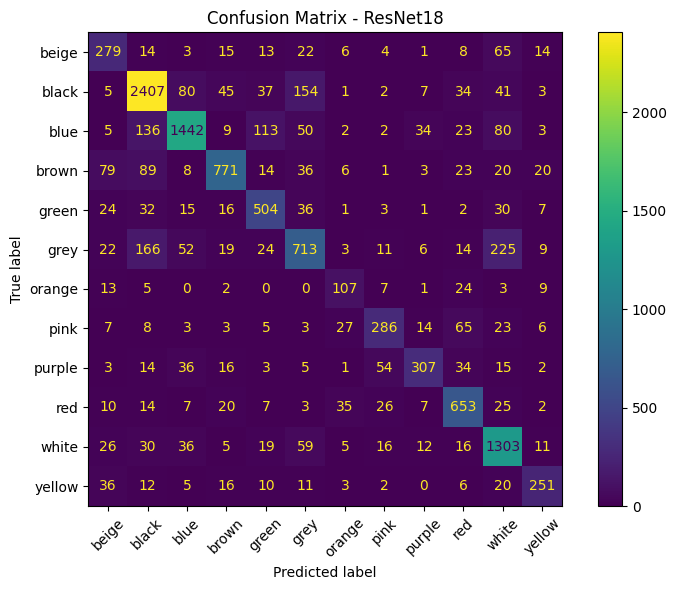


===== EfficientNet =====
              precision    recall  f1-score   support

       beige       0.59      0.63      0.61       444
       black       0.82      0.87      0.85      2816
        blue       0.85      0.77      0.81      1899
       brown       0.77      0.78      0.78      1070
       green       0.73      0.77      0.75       671
        grey       0.68      0.62      0.64      1264
      orange       0.72      0.46      0.56       171
        pink       0.70      0.70      0.70       450
      purple       0.73      0.73      0.73       490
         red       0.75      0.85      0.79       809
       white       0.77      0.80      0.78      1538
      yellow       0.78      0.58      0.67       372

    accuracy                           0.77     11994
   macro avg       0.74      0.71      0.72     11994
weighted avg       0.77      0.77      0.77     11994



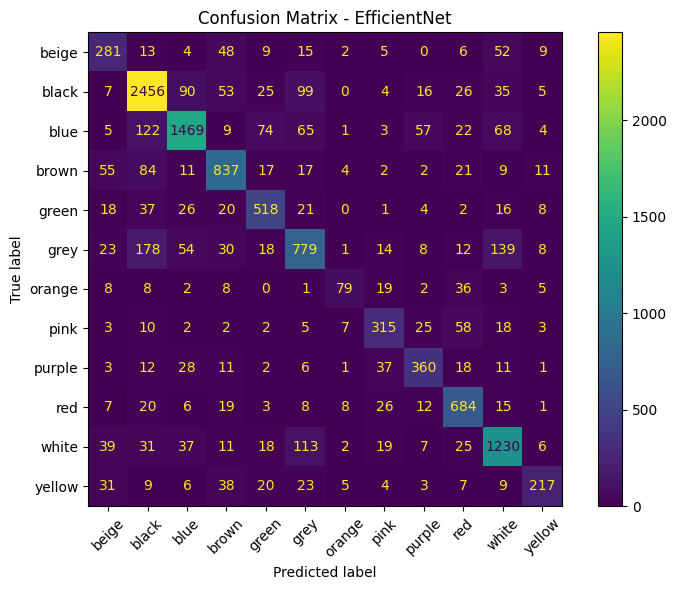


===== ViT =====
              precision    recall  f1-score   support

       beige       0.62      0.56      0.59       444
       black       0.85      0.84      0.84      2816
        blue       0.81      0.86      0.83      1899
       brown       0.75      0.76      0.76      1070
       green       0.80      0.70      0.74       671
        grey       0.63      0.67      0.65      1264
      orange       0.67      0.54      0.60       171
        pink       0.69      0.72      0.71       450
      purple       0.80      0.64      0.71       490
         red       0.72      0.85      0.78       809
       white       0.82      0.72      0.77      1538
      yellow       0.58      0.79      0.67       372

    accuracy                           0.77     11994
   macro avg       0.73      0.72      0.72     11994
weighted avg       0.77      0.77      0.77     11994



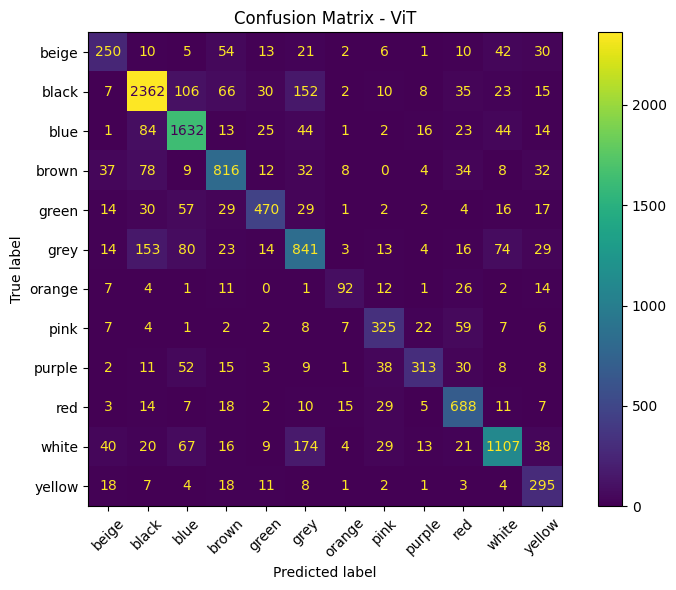

In [73]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

def get_predictions(model, loader, device, task_name):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            # get true labels for the requested task
            true_labels = labels[task_name].to(device)

            # model returns dict of outputs
            outputs = model(images)
            task_outputs = outputs[task_name]

            preds = task_outputs.argmax(dim=1)

            y_true.extend(true_labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred


models_and_loaders = {
    "SimpleCNN": (model_scratch, val_loader),
    "ResNet18": (model_resnet, val_loader_resnet),
    "EfficientNet": (model_effnet, val_loader_effnet),
    "ViT": (model_vit, val_loader),   # same loader as scratch
}

class_names = list(color_encoder.classes_)

for name, (model_instance, loader_instance) in models_and_loaders.items():
    print(f"\n===== {name} =====")

    y_true, y_pred = get_predictions(model_instance, loader_instance, device, "color")

    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, xticks_rotation=45)
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

Performance is analyzed using classification reports and confusion matrices.

The overall accuracy comparison across models shows a clear improvement when using transfer learning approaches:

- SimpleCNN: **0.67**
- ResNet18: **0.75**
- EfficientNet-B0: **0.77**
- ViT-B/16: **0.77**

Key observations:
- Transfer learning significantly improves performance over the baseline model.
- EfficientNet-B0 and ViT achieve the highest accuracy (~77%).
- ResNet18 provides a strong balance between performance and computational cost.
- SimpleCNN performs noticeably worse, indicating limited feature extraction capability.

The confusion matrices reveal consistent patterns across all models.

Strongly predicted classes:
- Black, Blue, White, Red
- These classes have distinct visual features and are easier to learn
- High precision and recall across all architectures

Weak or confusing classes:

- **Beige**
  - Low precision and recall
  - Confused with: white, brown, yellow
  - Reason: lacks clear visual boundaries

- **Grey**
  - Confused with: white, black
  - Reason: grayscale ambiguity

- **Orange**
  - Lowest recall across models
  - Confused with: red, brown
  - Likely causes:
    - Small sample size (~171 samples)
    - High similarity to neighboring colors

- **Yellow**
  - Mixed performance across models
  - ViT performs better than EfficientNet
  - Suggests better handling of subtle color differences

Model-level comparison:

- **SimpleCNN**
  - Weak overall performance
  - High confusion between similar colors
  - Lacks deep feature extraction

- **ResNet18**
  - Strong improvement over baseline
  - Cleaner confusion matrix (strong diagonal)
  - Best efficiency vs performance trade-off

- **EfficientNet-B0**
  - Highest overall accuracy
  - Strong across most classes
  - Slight drop on minority classes (e.g., orange)

- **ViT-B/16**
  - Comparable to EfficientNet
  - Slight advantage on subtle classes (e.g., yellow)
  - Significantly higher training time (~80 min)

Important factors affecting performance:

- **Class imbalance**
  - Example: orange (171 samples) vs black (2816 samples)
  - Leads to bias toward dominant classes

- **Color ambiguity**
  - Classes like beige and grey overlap with others
  - Hard even for advanced models to separate

- **Label quality**
  - Possible inconsistencies in labeling
  - Adds noise to training

Final conclusions:

- Best overall model: **EfficientNet-B0**
- Best practical model: **ResNet18**
- ViT:
  - Strong performance
  - Not cost-effective for this task
- Key insight:
  - Data quality and class definition impact performance more than model complexity

Potential improvements:

- Data-focused:
  - Balance dataset across classes
  - Merge ambiguous classes (e.g., beige + brown)
  - Improve labeling consistency

- Model-focused:
  - Apply class weighting
  - Use focal loss
  - Add color-aware features (e.g., histograms)

In [77]:
comparison_df = pd.DataFrame([
    {
        "Model": "SimpleCNN",
        "Category Acc": 0.9290,
        "Gender Acc": 0.7390,
        "Color Acc": 0.6748,
        "Training Time": "~6 min",
        "Notes": "Baseline model trained from scratch"
    },
    {
        "Model": "ResNet18",
        "Category Acc": 0.9962,
        "Gender Acc": 0.9261,
        "Color Acc": 0.7630,
        "Training Time": "~6-7 min",
        "Notes": "Best efficiency/performance balance"
    },
    {
        "Model": "EfficientNet-B0",
        "Category Acc": 0.9968,
        "Gender Acc": 0.9324,
        "Color Acc": 0.7751,
        "Training Time": "~16 min",
        "Notes": "Best overall accuracy"
    },
    {
        "Model": "ViT-B/16",
        "Category Acc": 0.9962,
        "Gender Acc": 0.9284,
        "Color Acc": 0.7663,
        "Training Time": "~80 min",
        "Notes": "Strong but computationally expensive"
    },
])

comparison_df

,Model,Category Acc,Gender Acc,Color Acc,Training Time,Notes
0,SimpleCNN,0.9290,0.7390,0.6748,~6 min,Baseline model trained from scratch
1,ResNet18,0.9962,0.9261,0.7630,~6-7 min,Best efficiency/performance balance
2,EfficientNet-B0,0.9968,0.9324,0.7751,~16 min,Best overall accuracy
3,ViT-B/16,0.9962,0.9284,0.7663,~80 min,Strong but computationally expensive


EfficientNet-B0 achieved the highest overall validation performance, especially on color prediction, which was the most challenging task in this project.

However, ResNet18 delivered very similar results while requiring much less training time and computational cost.

For this reason:
- **EfficientNet-B0** is selected as the best-performing model,
- **ResNet18** is considered the most practical deployment option for the FitFolio application.

### Try Improve the Chosen Model

1. Keep the original ResNet18 result as the baseline
2. Improve the color task with class weighting
3. Increase the importance of color loss in the multi-task loss
4. Review augmentations to make sure they do not distort color information
5. Fine-tune more backbone layers with a smaller learning rate
6. Compare improved ResNet18 against the original ResNet18

In [80]:
train_df.head()

,id,gender,masterCategory,baseColour,color_12,image_path,file_exists,category_label,gender_label,color_label
42445,16181,men,Shoes,Black,black,data/images/16181.jpg,True,2,0,1
16730,58304,men,Accessories,Black,black,data/images/58304.jpg,True,0,0,1
41646,38688,women,Accessories,Grey,grey,data/images/38688.jpg,True,0,2,5
28900,45742,women,Apparel,Mustard,yellow,data/images/45742.jpg,True,1,2,11
28869,22644,men,Apparel,Navy Blue,blue,data/images/22644.jpg,True,1,0,2


In [81]:
# Compute color class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

# encoded color labels from training set
y_color_train = train_df["color_label"].values

# all class ids
classes = np.sort(train_df["color_label"].unique())

# compute balanced weights
color_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_color_train
)

# convert to tensor for PyTorch
color_class_weights = torch.tensor(color_class_weights, dtype=torch.float32).to(device)

print("Classes:", classes)
print("Color class weights:", color_class_weights)

Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Color class weights: tensor([2.2952, 0.3589, 0.5279, 0.9620, 1.4350, 0.7574, 5.5921, 2.2103, 2.0765,
        1.2133, 0.6661, 2.5739], device='mps:0')


In [83]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained ResNet18 backbone
resnet_backbone_weighted = resnet18(weights=ResNet18_Weights.DEFAULT)

# Extract feature size and remove original classifier
in_features = resnet_backbone_weighted.fc.in_features
resnet_backbone_weighted.fc = nn.Identity()


class ResNetMultiHead(nn.Module):
    """
    Multi-task classifier built on top of a pretrained ResNet18 backbone.
    """

    def __init__(self, backbone, num_categories, num_genders, num_colors):
        super().__init__()
        self.backbone = backbone

        self.fc_shared = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU()
        )

        self.category_head = nn.Linear(256, num_categories)
        self.gender_head = nn.Linear(256, num_genders)
        self.color_head = nn.Linear(256, num_colors)

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc_shared(x)

        return {
            "category": self.category_head(x),
            "gender": self.gender_head(x),
            "color": self.color_head(x),
        }


model_resnet_weighted = ResNetMultiHead(
    resnet_backbone_weighted,
    num_categories,
    num_genders,
    num_colors
).to(device)

print(model_resnet_weighted)

ResNetMultiHead(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

In [ ]:
import torch.nn as nn

category_criterion = nn.CrossEntropyLoss()
gender_criterion = nn.CrossEntropyLoss()
color_criterion = nn.CrossEntropyLoss(weight=color_class_weights)

optimizer_resnet_weighted = torch.optim.Adam(model_resnet_weighted.parameters(), lr=1e-4)

In [85]:
def train_one_epoch_weighted(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        category_labels = labels["category"].to(device)
        gender_labels = labels["gender"].to(device)
        color_labels = labels["color"].to(device)

        optimizer.zero_grad()

        outputs = model(images)

        category_loss = category_criterion(outputs["category"], category_labels)
        gender_loss = gender_criterion(outputs["gender"], gender_labels)
        color_loss = color_criterion(outputs["color"], color_labels)

        loss = category_loss + gender_loss + color_loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [86]:
def evaluate_weighted(model, loader, device):
    model.eval()
    running_loss = 0.0

    category_correct = 0
    gender_correct = 0
    color_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            category_labels = labels["category"].to(device)
            gender_labels = labels["gender"].to(device)
            color_labels = labels["color"].to(device)

            outputs = model(images)

            category_loss = category_criterion(outputs["category"], category_labels)
            gender_loss = gender_criterion(outputs["gender"], gender_labels)
            color_loss = color_criterion(outputs["color"], color_labels)

            loss = category_loss + gender_loss + color_loss
            running_loss += loss.item()

            category_preds = outputs["category"].argmax(dim=1)
            gender_preds = outputs["gender"].argmax(dim=1)
            color_preds = outputs["color"].argmax(dim=1)

            category_correct += (category_preds == category_labels).sum().item()
            gender_correct += (gender_preds == gender_labels).sum().item()
            color_correct += (color_preds == color_labels).sum().item()

            total += images.size(0)

    return {
        "loss": running_loss / len(loader),
        "category_acc": category_correct / total,
        "gender_acc": gender_correct / total,
        "color_acc": color_correct / total
    }

In [87]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_one_epoch_weighted(
        model_resnet_weighted,
        train_loader_resnet,
        optimizer_resnet_weighted,
        device
    )

    val_metrics = evaluate_weighted(
        model_resnet_weighted,
        val_loader_resnet,
        device
    )

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f}")
    print(f"Val Category Acc: {val_metrics['category_acc']:.4f}")
    print(f"Val Gender Acc: {val_metrics['gender_acc']:.4f}")
    print(f"Val Color Acc: {val_metrics['color_acc']:.4f}")
    print("-" * 40)

Epoch 1/5
Train Loss: 1.5243
Val Loss: 1.1553
Val Category Acc: 0.9935
Val Gender Acc: 0.9141
Val Color Acc: 0.7079
----------------------------------------
Epoch 2/5
Train Loss: 1.0176
Val Loss: 1.1428
Val Category Acc: 0.9947
Val Gender Acc: 0.9205
Val Color Acc: 0.7078
----------------------------------------
Epoch 3/5
Train Loss: 0.7931
Val Loss: 1.0719
Val Category Acc: 0.9949
Val Gender Acc: 0.9280
Val Color Acc: 0.7426
----------------------------------------
Epoch 4/5
Train Loss: 0.6070
Val Loss: 1.1354
Val Category Acc: 0.9957
Val Gender Acc: 0.9283
Val Color Acc: 0.7508
----------------------------------------
Epoch 5/5
Train Loss: 0.4364
Val Loss: 1.3101
Val Category Acc: 0.9955
Val Gender Acc: 0.9261
Val Color Acc: 0.7439
----------------------------------------


In [88]:
def train_one_epoch_weighted(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        category_labels = labels["category"].to(device)
        gender_labels = labels["gender"].to(device)
        color_labels = labels["color"].to(device)

        optimizer.zero_grad()

        outputs = model(images)

        category_loss = category_criterion(outputs["category"], category_labels)
        gender_loss = gender_criterion(outputs["gender"], gender_labels)
        color_loss = color_criterion(outputs["color"], color_labels)

        loss = category_loss + gender_loss + 2.0 * color_loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [89]:
category_criterion = nn.CrossEntropyLoss()
gender_criterion = nn.CrossEntropyLoss()
color_criterion = nn.CrossEntropyLoss()

Because the previous experiment suggests weighted classes alone did not help much. Now we want to test whether the issue is that color is under-prioritized in multi-task learning.

In [90]:
num_epochs = 4

for epoch in range(num_epochs):
    train_loss = train_one_epoch_weighted(
        model_resnet_weighted,
        train_loader_resnet,
        optimizer_resnet_weighted,
        device
    )

    val_metrics = evaluate_weighted(
        model_resnet_weighted,
        val_loader_resnet,
        device
    )

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f}")
    print(f"Val Category Acc: {val_metrics['category_acc']:.4f}")
    print(f"Val Gender Acc: {val_metrics['gender_acc']:.4f}")
    print(f"Val Color Acc: {val_metrics['color_acc']:.4f}")
    print("-" * 40)

Epoch 1/4
Train Loss: 0.8740
Val Loss: 1.1699
Val Category Acc: 0.9961
Val Gender Acc: 0.9275
Val Color Acc: 0.7371
----------------------------------------
Epoch 2/4
Train Loss: 0.4622
Val Loss: 1.3137
Val Category Acc: 0.9959
Val Gender Acc: 0.9288
Val Color Acc: 0.7425
----------------------------------------
Epoch 3/4
Train Loss: 0.3178
Val Loss: 1.4453
Val Category Acc: 0.9953
Val Gender Acc: 0.9300
Val Color Acc: 0.7452
----------------------------------------
Epoch 4/4
Train Loss: 0.2765
Val Loss: 1.6474
Val Category Acc: 0.9937
Val Gender Acc: 0.9290
Val Color Acc: 0.7264
----------------------------------------


### Reject Image Based on Confidence

To reduce incorrect predictions on poor-quality or irrelevant uploads, the application can use a confidence-based rejection rule.

Instead of always accepting the top predicted label, the system first checks whether the model is sufficiently confident in its prediction. If confidence is too low, the image can be rejected and the user can be asked to upload a clearer product image.

In [74]:
def predict_with_confidence(model, image_path, transform, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)

        category_probs = torch.softmax(outputs["category"], dim=1)
        gender_probs = torch.softmax(outputs["gender"], dim=1)
        color_probs = torch.softmax(outputs["color"], dim=1)

        category_conf, category_pred = torch.max(category_probs, dim=1)
        gender_conf, gender_pred = torch.max(gender_probs, dim=1)
        color_conf, color_pred = torch.max(color_probs, dim=1)

    result = {
        "category": category_encoder.inverse_transform([category_pred.item()])[0],
        "gender": gender_encoder.inverse_transform([gender_pred.item()])[0],
        "color": color_encoder.inverse_transform([color_pred.item()])[0],
        "category_confidence": float(category_conf.item()),
        "gender_confidence": float(gender_conf.item()),
        "color_confidence": float(color_conf.item()),
    }

    return result

In [75]:
sample_result = predict_with_confidence(
    model_resnet,         
    df.iloc[0]["image_path"],
    val_transform_resnet, 
    device
)

sample_result

{'category': 'Apparel',
 'gender': 'men',
 'color': 'blue',
 'category_confidence': 0.9999983310699463,
 'gender_confidence': 0.9999969005584717,
 'color_confidence': 0.915083110332489}

In [76]:
def should_reject_prediction(prediction, threshold=0.60):
    return prediction["category_confidence"] < threshold

A simple initial rejection rule is based on category confidence.

If the confidence score is below a threshold such as **0.60**, the application can reject the image and ask the user to upload a clearer or more relevant product image.

This is a lightweight alternative to training a separate image-validity classifier.

### Infere with FitFolio Items

In [91]:
from PIL import Image
import torch

def predict_single_image(
    image_path,
    model,
    transform,
    device,
    category_encoder,
    gender_encoder,
    color_encoder
):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)  # add batch dim

    with torch.no_grad():
        category_logits, gender_logits, color_logits = model(image_tensor)

        category_pred = torch.argmax(category_logits, dim=1).item()
        gender_pred = torch.argmax(gender_logits, dim=1).item()
        color_pred = torch.argmax(color_logits, dim=1).item()

    category_label = category_encoder.inverse_transform([category_pred])[0]
    gender_label = gender_encoder.inverse_transform([gender_pred])[0]
    color_label = color_encoder.inverse_transform([color_pred])[0]

    return {
        "category": category_label,
        "gender": gender_label,
        "color": color_label
    }

In [92]:
result = predict_single_image(
    image_path="fitfolio_data/item_1.jpeg",
    model=model_resnet,
    transform=val_transform_resnet,
    device=device,
    category_encoder=category_encoder,
    gender_encoder=gender_encoder,
    color_encoder=color_encoder
)

print(result)

TypeError: argmax(): argument 'input' (position 1) must be Tensor, not str

In [93]:
def predict_single_image(
    image_path,
    model,
    transform,
    device,
    category_encoder,
    gender_encoder,
    color_encoder
):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)

        category_logits = outputs["category"]
        gender_logits = outputs["gender"]
        color_logits = outputs["color"]

        category_pred = torch.argmax(category_logits, dim=1).item()
        gender_pred = torch.argmax(gender_logits, dim=1).item()
        color_pred = torch.argmax(color_logits, dim=1).item()

    category_label = category_encoder.inverse_transform([category_pred])[0]
    gender_label = gender_encoder.inverse_transform([gender_pred])[0]
    color_label = color_encoder.inverse_transform([color_pred])[0]

    return {
        "category": category_label,
        "gender": gender_label,
        "color": color_label
    }

In [96]:
image = Image.open("fitfolio_data/item_1.jpeg").convert("RGB")
image_tensor = val_transform_resnet(image).unsqueeze(0).to(device)

outputs = model_resnet(image_tensor)
print(type(outputs))
print(outputs)

<class 'dict'>
{'category': tensor([[-2.9526, -2.3884,  0.1565]], device='mps:0',
       grad_fn=<LinearBackward0>), 'gender': tensor([[ 2.3410, -4.4830, -4.6332]], device='mps:0',
       grad_fn=<LinearBackward0>), 'color': tensor([[ 1.5435,  0.8558,  1.2423, -2.7482, -1.3829, -0.7360, -3.0839, -4.5727,
         -5.7432, -4.2162,  8.8129, -3.3012]], device='mps:0',
       grad_fn=<LinearBackward0>)}


In [98]:
from PIL import Image
import torch

def predict_single_image(
    image_path,
    model,
    transform,
    device,
    category_encoder,
    gender_encoder,
    color_encoder
):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)

        category_logits = outputs["category"]
        gender_logits = outputs["gender"]
        color_logits = outputs["color"]

        category_pred = torch.argmax(category_logits, dim=1).item()
        gender_pred = torch.argmax(gender_logits, dim=1).item()
        color_pred = torch.argmax(color_logits, dim=1).item()

    category_label = category_encoder.inverse_transform([category_pred])[0]
    gender_label = gender_encoder.inverse_transform([gender_pred])[0]
    color_label = color_encoder.inverse_transform([color_pred])[0]

    return {
        "category": category_label,
        "gender": gender_label,
        "color": color_label
    }

In [99]:
result = predict_single_image(
    image_path="fitfolio_data/item_1.jpeg",
    model=model_resnet,
    transform=val_transform_resnet,
    device=device,
    category_encoder=category_encoder,
    gender_encoder=gender_encoder,
    color_encoder=color_encoder
)

print(result)

{'category': 'Shoes', 'gender': 'men', 'color': 'white'}


In [101]:
result = predict_single_image(
    image_path="fitfolio_data/item_2.jpg",
    model=model_resnet,
    transform=val_transform_resnet,
    device=device,
    category_encoder=category_encoder,
    gender_encoder=gender_encoder,
    color_encoder=color_encoder
)

print(result)

{'category': 'Apparel', 'gender': 'men', 'color': 'blue'}


In [102]:
result = predict_single_image(
    image_path="fitfolio_data/item_3.jpeg",
    model=model_resnet,
    transform=val_transform_resnet,
    device=device,
    category_encoder=category_encoder,
    gender_encoder=gender_encoder,
    color_encoder=color_encoder
)

print(result)

{'category': 'Apparel', 'gender': 'men', 'color': 'beige'}


In [109]:
result = predict_single_image(
    image_path="fitfolio_data/item_4.jpg",
    model=model_resnet,
    transform=val_transform_resnet,
    device=device,
    category_encoder=category_encoder,
    gender_encoder=gender_encoder,
    color_encoder=color_encoder
)

print(result)

{'category': 'Apparel', 'gender': 'women', 'color': 'beige'}


In [110]:
result = predict_single_image(
    image_path="fitfolio_data/item_5.jpg",
    model=model_resnet,
    transform=val_transform_resnet,
    device=device,
    category_encoder=category_encoder,
    gender_encoder=gender_encoder,
    color_encoder=color_encoder
)

print(result)

{'category': 'Apparel', 'gender': 'women', 'color': 'red'}


In [111]:
sample_result = predict_with_confidence(
    model_resnet,
    df.iloc[0]["image_path"],
    val_transform_resnet,
    device
)

print(sample_result)
print("Reject?", should_reject_prediction(sample_result, threshold=0.60))

{'category': 'Apparel', 'gender': 'men', 'color': 'blue', 'category_confidence': 0.9999983310699463, 'gender_confidence': 0.9999969005584717, 'color_confidence': 0.915083110332489}
Reject? False


In [114]:
result = predict_with_confidence(
    model_resnet,
    "fitfolio_data/item_1.jpeg",
    val_transform_resnet,
    device
)

print(result)
print("Reject?", should_reject_prediction(result, threshold=0.60))

{'category': 'Shoes', 'gender': 'men', 'color': 'white', 'category_confidence': 0.8903743028640747, 'gender_confidence': 0.9979810118675232, 'color_confidence': 0.998306155204773}
Reject? False


In [115]:
result = predict_with_confidence(
    model_resnet,
    "fitfolio_data/item_6.jpeg",
    val_transform_resnet,
    device
)

print(result)
print("Reject?", should_reject_prediction(result, threshold=0.60))

{'category': 'Shoes', 'gender': 'men', 'color': 'black', 'category_confidence': 0.5253515243530273, 'gender_confidence': 0.9311460256576538, 'color_confidence': 0.9883310198783875}
Reject? True


In [116]:
result = predict_with_confidence(
    model_resnet,
    "fitfolio_data/item_7.jpeg",
    val_transform_resnet,
    device
)

print(result)
print("Reject?", should_reject_prediction(result, threshold=0.60))

{'category': 'Accessories', 'gender': 'men', 'color': 'white', 'category_confidence': 0.6802180409431458, 'gender_confidence': 0.9318679571151733, 'color_confidence': 0.6744521856307983}
Reject? False


So, I would increase the confidence

In [119]:
result = predict_with_confidence(
    model_resnet,
    "fitfolio_data/item_7.jpeg",
    val_transform_resnet,
    device
)

print(result)
print("Reject?", should_reject_prediction(result, threshold=0.70))

{'category': 'Accessories', 'gender': 'men', 'color': 'white', 'category_confidence': 0.6802180409431458, 'gender_confidence': 0.9318679571151733, 'color_confidence': 0.6744521856307983}
Reject? True


#### Background removal (rembg)

Use this to strip backgrounds and save a transparent PNG (handy for catalog cutouts). Requires `pip install rembg` in the notebook kernel environment.

In [124]:
from pathlib import Path
from rembg import remove
def remove_background_save(input_path: str | Path, output_path: str | Path) -> Path:
  src = Path(input_path)
  dst = Path(output_path)
  if not src.is_file():
      raise FileNotFoundError(f"Input image not found: {src}")
  dst.parent.mkdir(parents=True, exist_ok=True)
  dst.write_bytes(remove(src.read_bytes()))
  return dst.resolve()
# --- run once ---
inp = Path("test_items_set/item_21.jpeg")  # or IMAGES_DIR / "15970.jpg", etc.
out = Path("test_items_set/item_21_nobg.png")
remove_background_save(inp, out)
print("Saved:", out.resolve())

/Users/akudenko/Documents/FitFolio/fitfolio/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved: /Users/akudenko/Documents/FitFolio/fitfolio/fitfolio-ml-api/notebooks/test_items_set/item_21_nobg.png


### Batch inference: `test_items_set` → CSV

Run after training/loading `model_resnet`, `val_transform_resnet`, `device`, and `predict_with_confidence` are defined. Produces `test_items_set/test_items_predictions.csv` with columns `id` (image stem, e.g. `item_1`), `category`, `gender`, `color`.

In [120]:
TEST_ITEMS_DIR = Path("test_items_set")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

if not TEST_ITEMS_DIR.is_dir():
    raise FileNotFoundError(f"Missing folder: {TEST_ITEMS_DIR.resolve()}")

image_paths = [
    p
    for p in TEST_ITEMS_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]


def _test_image_sort_key(path: Path) -> tuple:
    stem = path.stem
    if stem.startswith("item_"):
        try:
            return (0, int(stem.split("_", 1)[1]))
        except ValueError:
            pass
    return (1, stem)


image_paths.sort(key=_test_image_sort_key)

rows = []
for image_path in image_paths:
    pred = predict_with_confidence(
        model_resnet,
        image_path,
        val_transform_resnet,
        device,
    )
    rows.append(
        {
            "id": image_path.stem,
            "category": pred["category"],
            "gender": pred["gender"],
            "color": pred["color"],
        }
    )

test_items_results_df = pd.DataFrame(rows)
csv_out = TEST_ITEMS_DIR / "test_items_predictions.csv"
test_items_results_df.to_csv(csv_out, index=False)
print(f"Saved {len(test_items_results_df)} rows to {csv_out.resolve()}")
test_items_results_df

Saved 20 rows to /Users/akudenko/Documents/FitFolio/fitfolio/fitfolio-ml-api/notebooks/test_items_set/test_items_predictions.csv


,id,category,gender,color
0,item_1,Shoes,men,white
1,item_2,Apparel,men,blue
2,item_3,Apparel,men,beige
3,item_4,Apparel,men,white
4,item_5,Apparel,women,red
5,item_6,Apparel,women,beige
6,item_7,Apparel,women,white
7,item_8,Apparel,men,blue
8,item_9,Apparel,men,black
9,item_10,Accessories,women,brown


In [121]:
import torch
from pathlib import Path

out = Path("exports")  # or any folder you want
out.mkdir(parents=True, exist_ok=True)

artifact = {
    "state_dict": model_resnet.state_dict(),
    "num_categories": num_categories,
    "num_genders": num_genders,
    "num_colors": num_colors,
}
torch.save(artifact, out / "resnet_item_classifier.pt")

In [122]:
import json

labels = {
    "category": category_encoder.classes_.tolist(),
    "gender": gender_encoder.classes_.tolist(),
    "color": color_encoder.classes_.tolist(),
}
(out / "label_classes.json").write_text(json.dumps(labels, indent=2))

296